# Trí tuệ nhân tạo: phân loại trực tiếp SAFE/TOXIC trên ViHSD

Notebook tự chứa toàn bộ code, không phụ thuộc project/source bên ngoài. Ground truth được đổi **trước khi fit**: `CLEAN → SAFE`, `OFFENSIVE/HATE → TOXIC`. ViHSD không có nhãn tin giả, cạnh tương tác hoặc timestamp; đây chỉ là hệ thống sàng lọc ngôn từ độc hại có human review. Không ô nào hiển thị bình luận thô.

## 1. Cấu hình chế độ chạy
`SMOKE` chỉ dùng QA; kết quả báo cáo phải dùng `FULL`. `FULL_WITH_NEURAL` cần GPU.

In [1]:
RUN_MODE = "SMOKE"  # @param ["SMOKE", "FULL", "FULL_WITH_NEURAL"]
SEED = 42
CONFIRM_TEST_AFTER_LOCK = True
assert RUN_MODE in {"SMOKE", "FULL", "FULL_WITH_NEURAL"}
print(f"RUN_MODE={RUN_MODE}, seed={SEED}")

RUN_MODE=SMOKE, seed=42


## 2. Cài dependency, tải commit cố định và kiểm SHA-256

In [2]:
from IPython import get_ipython
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("pip", "install -q pandas scikit-learn joblib matplotlib pyyaml 'huggingface-hub>=0.34,<1' 'underthesea @ git+https://github.com/undertheseanlp/underthesea.git@3f5a619799c61d630bb4eb622c048d8cfdce5e76'")
    if RUN_MODE == "FULL_WITH_NEURAL":
        ipython.run_line_magic("pip", "install -q 'huggingface-hub>=0.34,<1' torch transformers accelerate")

In [3]:
from __future__ import annotations
import hashlib, json, math, random, re, time, unicodedata, urllib.request, warnings, zipfile
from collections import Counter
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from underthesea import word_tokenize

VIHSD_COMMIT = "70fe50c9c94145e3b9be5614a048cbd5b480fa54"
VIHSD_URL = f"https://raw.githubusercontent.com/sonlam1102/vihsd/{VIHSD_COMMIT}/data/vihsd.zip"
VIHSD_SHA256 = "1d823c4c86a8aede83555c64da4e1be24146967aac6b30cdaf8603d4910f328d"
DATA_PATH = Path("/content/vihsd.zip") if Path("/content").exists() else Path("vihsd.zip")
OUTPUT_DIR = (Path("/content/vihsd_ai_outputs") if Path("/content").exists() else Path("outputs/notebook_run"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()
if not DATA_PATH.exists() or sha256_file(DATA_PATH) != VIHSD_SHA256:
    urllib.request.urlretrieve(VIHSD_URL, DATA_PATH)
assert sha256_file(DATA_PATH) == VIHSD_SHA256, "Checksum mismatch: stop before reading data"
print("ViHSD checksum verified")

ViHSD checksum verified


## 3. Nạp train/dev và ánh xạ ground truth trước khi huấn luyện
Hàm chỉ đọc member được yêu cầu; test chưa được mở ở giai đoạn này.

In [4]:
SOURCE_TO_BINARY = {"CLEAN": "SAFE", "OFFENSIVE": "TOXIC", "HATE": "TOXIC"}
ID_TO_SOURCE = {0: "CLEAN", 1: "OFFENSIVE", 2: "HATE"}
BINARY_LABELS = ["SAFE", "TOXIC"]
def load_vihsd_split(split):
    with zipfile.ZipFile(DATA_PATH) as archive:
        with archive.open(f"vihsd/{split}.csv") as stream:
            raw = pd.read_csv(stream)
    source = raw["label_id"].astype(int).map(ID_TO_SOURCE)
    if source.isna().any():
        raise ValueError("Unknown ViHSD ground-truth label")
    frame = pd.DataFrame({"text": raw["free_text"].fillna("").astype(str), "source_label": source})
    frame["label"] = frame["source_label"].map(SOURCE_TO_BINARY)  # remap BEFORE fit
    assert set(frame["label"]) <= set(BINARY_LABELS)
    return frame
def stratified_sample(frame, size, seed):
    if len(frame) <= size:
        return frame.reset_index(drop=True)
    pieces = []
    for offset, (_, group) in enumerate(frame.groupby("label")):
        count = max(2, round(size * len(group) / len(frame)))
        pieces.append(group.sample(n=min(count, len(group)), random_state=seed + offset))
    sampled = pd.concat(pieces, ignore_index=True)
    return sampled.sample(n=size, random_state=seed).reset_index(drop=True)
train_df = load_vihsd_split("train")
dev_df = load_vihsd_split("dev")
if RUN_MODE == "SMOKE":
    train_df = stratified_sample(train_df, 600, SEED)
    dev_df = stratified_sample(dev_df, 240, SEED + 1)
aggregate = {name: {"rows": len(frame), **{label: int((frame.label == label).sum()) for label in BINARY_LABELS}} for name, frame in {"train": train_df, "dev": dev_df}.items()}
print(aggregate)  # aggregate only; never raw comments

{'train': {'rows': 600, 'SAFE': 496, 'TOXIC': 104}, 'dev': {'rows': 240, 'SAFE': 197, 'TOXIC': 43}}


## 4. Audit riêng tư
Chỉ thống kê độ dài, tín hiệu và fingerprint có domain separator; không lưu raw text/source ID.

In [5]:
def fingerprint(text):
    return hashlib.sha256(b"vihsd-ai-notebook-v1\0" + text.encode("utf-8", errors="replace")).hexdigest()
def private_audit(frame):
    lengths = frame.text.str.len()
    return {"rows": len(frame), "binary_distribution": frame.label.value_counts().to_dict(), "source_distribution": frame.source_label.value_counts().to_dict(), "length": {"min": int(lengths.min()), "median": float(lengths.median()), "mean": float(lengths.mean()), "max": int(lengths.max())}, "contains_url": int(frame.text.str.contains(r"https?://|www\.", case=False, regex=True).sum()), "unique_fingerprints": len({fingerprint(text) for text in frame.text})}
audit = {"privacy": "aggregate_only", "train": private_audit(train_df), "dev": private_audit(dev_df)}
(OUTPUT_DIR / "audit_train_dev.json").write_text(json.dumps(audit, ensure_ascii=False, indent=2), encoding="utf-8")

## 5. Tiền xử lý social text tiếng Việt
Thứ tự: Unicode/lowercase → URL → icon/emoji → ký tự lặp → teen code → `underthesea` → stopword. Từ phủ định được giữ.

In [6]:
TEEN_CODE = {"ko": "không", "k": "không", "hok": "không", "dc": "được", "đc": "được", "mik": "mình", "mk": "mình", "mn": "mọi_người", "j": "gì", "z": "vậy", "vs": "với", "cx": "cũng", "nt": "nhắn_tin", "rep": "trả_lời"}
STOPWORDS = {"ạ", "à", "ấy", "bị", "bởi", "các", "cái", "cho", "của", "cùng", "đã", "đang", "đây", "để", "đến", "đó", "được", "là", "lại", "mà", "một", "này", "những", "ở", "rằng", "rất", "thì", "trên", "trong", "từ", "và", "với"}
WORD_RE = re.compile(r"(?u)\b[\wÀ-ỹ]+\b")
EMOJI_RE = re.compile("[\U0001F300-\U0001FAFF\u2600-\u27BF]")
class SocialPreprocessor(BaseEstimator, TransformerMixin):
    def fit(self, texts, y=None): return self
    def normalize_one(self, value):
        text = unicodedata.normalize("NFC", str(value)).lower()
        text = re.sub(r"(?:https?://|www\.)\S+", " urltoken ", text)
        text = re.sub(r"(?::|;|=)-?(?:\)|D|\])", " iconpositive ", text)
        text = re.sub(r"(?::|;|=)-?(?:\(|/|\\)", " iconnegative ", text)
        text = EMOJI_RE.sub(" emojitoken ", text)
        text = re.sub(r"([^\W\d_])\1{2,}", r"\1\1", text)
        text = WORD_RE.sub(lambda m: TEEN_CODE.get(m.group(0), m.group(0)), text)
        segmented = word_tokenize(text, format="text")
        return " ".join(token for token in segmented.split() if token not in STOPWORDS)
    def transform(self, texts): return [self.normalize_one(text) for text in texts]

## 6–7. Ba baseline nhị phân, train/dev và selection
TF-IDF nằm trong từng Pipeline và chỉ `fit` trên train. Xếp hạng: dev Macro-F1 giảm dần → dev TOXIC Recall giảm dần → tên model.

In [7]:
random.seed(SEED); np.random.seed(SEED)
def make_pipeline(classifier):
    return Pipeline([("preprocess", SocialPreprocessor()), ("tfidf", TfidfVectorizer(ngram_range=(1,2), min_df=2, max_df=0.98, max_features=60000, sublinear_tf=True, lowercase=False, token_pattern=r"(?u)\b\w+\b")), ("classifier", classifier)])
MODELS = {"multinomial_nb": make_pipeline(MultinomialNB(alpha=0.5)), "logistic_regression": make_pipeline(LogisticRegression(C=2.0, max_iter=1500, class_weight="balanced", random_state=SEED, solver="liblinear")), "linear_svc": make_pipeline(LinearSVC(C=1.0, class_weight="balanced", random_state=SEED))}
def metrics(y_true, y_pred):
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=BINARY_LABELS, zero_division=0)
    mp, mr, mf, _ = precision_recall_fscore_support(y_true, y_pred, labels=BINARY_LABELS, average="macro", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=BINARY_LABELS)
    return {"accuracy": float(accuracy_score(y_true, y_pred)), "macro": {"precision": float(mp), "recall": float(mr), "f1": float(mf)}, "per_class": {label: {"precision": float(p[i]), "recall": float(r[i]), "f1": float(f[i]), "support": int(s[i])} for i, label in enumerate(BINARY_LABELS)}, "confusion_matrix": {"labels": BINARY_LABELS, "rows_true_columns_predicted": cm.tolist()}}
dev_rows = []
for name, model in MODELS.items():
    started = time.perf_counter()
    model.fit(train_df.text.tolist(), train_df.label.tolist())  # labels already binary
    assert set(model.named_steps["classifier"].classes_) == {"SAFE", "TOXIC"}
    dev_rows.append({"name": name, "fit_seconds": time.perf_counter()-started, "train": metrics(train_df.label, model.predict(train_df.text)), "dev": metrics(dev_df.label, model.predict(dev_df.text))})
ranked = sorted(dev_rows, key=lambda row: (-row["dev"]["macro"]["f1"], -row["dev"]["per_class"]["TOXIC"]["recall"], row["name"]))
selected_model = ranked[0]["name"]
pd.DataFrame([{"model": row["name"], "train_macro_f1": row["train"]["macro"]["f1"], "dev_macro_f1": row["dev"]["macro"]["f1"], "dev_toxic_recall": row["dev"]["per_class"]["TOXIC"]["recall"]} for row in ranked])

                 model  train_macro_f1  dev_macro_f1  dev_toxic_recall
0  logistic_regression        0.919578      0.650381          0.465116
1            linear_svc        0.953474      0.636934          0.441860
2        multinomial_nb        0.826923      0.575814          0.139535

## 8. Khóa model/config trước khi mở test

In [8]:
def write_json(path, payload):
    Path(path).write_text(json.dumps(payload, ensure_ascii=False, indent=2, sort_keys=True), encoding="utf-8")
artifact_path = OUTPUT_DIR / f"{selected_model}.joblib"
joblib.dump(MODELS[selected_model], artifact_path, compress=3)
dev_payload = {"test_consulted": False, "training_targets": BINARY_LABELS, "selection_rule": ["dev_macro_f1", "dev_toxic_recall"], "selected_model": selected_model, "models": ranked}
write_json(OUTPUT_DIR / "dev_results.json", dev_payload)
manifest = {"seed": SEED, "run_mode": RUN_MODE, "dataset_commit": VIHSD_COMMIT, "dataset_sha256": VIHSD_SHA256, "label_mapping_before_fit": SOURCE_TO_BINARY, "test_loaded_during_training": False, "result_status": "reproduction_post_hoc"}
write_json(OUTPUT_DIR / "manifest.json", manifest)
lock = {"locked": True, "locked_before_test": True, "test_opened": False, "selected_model": selected_model, "artifact": {"path": artifact_path.name, "sha256": sha256_file(artifact_path)}, "dev_results": {"path": "dev_results.json", "sha256": sha256_file(OUTPUT_DIR / "dev_results.json")}}
write_json(OUTPUT_DIR / "selection.lock.json", lock)
print("Selection locked before test")

Selection locked before test


## 9–10. Mở test sau khóa, full binary metrics và confusion matrix

In [9]:
assert CONFIRM_TEST_AFTER_LOCK, "Review dev selection then explicitly confirm test"
lock = json.loads((OUTPUT_DIR / "selection.lock.json").read_text(encoding="utf-8"))
assert lock["locked_before_test"] and not lock["test_opened"]
assert sha256_file(OUTPUT_DIR / lock["artifact"]["path"]) == lock["artifact"]["sha256"]
assert sha256_file(OUTPUT_DIR / lock["dev_results"]["path"]) == lock["dev_results"]["sha256"]
test_df = load_vihsd_split("test")  # first test read occurs after lock
if RUN_MODE == "SMOKE": test_df = stratified_sample(test_df, 400, SEED + 2)
frozen_model = joblib.load(OUTPUT_DIR / lock["artifact"]["path"])
test_prediction = frozen_model.predict(test_df.text.tolist())
test_metrics = metrics(test_df.label.tolist(), test_prediction)
test_payload = {"selected_model": selected_model, "refit_performed": False, "selection_performed_during_test": False, "test_used_for_fit_or_selection": False, "metrics": test_metrics, "result_status": "reproduction_post_hoc"}
write_json(OUTPUT_DIR / "test_results.json", test_payload)
lock["test_opened"] = True; lock["test_result_sha256"] = sha256_file(OUTPUT_DIR / "test_results.json")
write_json(OUTPUT_DIR / "selection.lock.json", lock)
pd.DataFrame({"metric": ["Accuracy", "Macro Precision", "Macro Recall", "Macro-F1", "SAFE F1", "TOXIC F1"], "value": [test_metrics["accuracy"], test_metrics["macro"]["precision"], test_metrics["macro"]["recall"], test_metrics["macro"]["f1"], test_metrics["per_class"]["SAFE"]["f1"], test_metrics["per_class"]["TOXIC"]["f1"]]})

            metric     value
0         Accuracy  0.825000
1  Macro Precision  0.688532
2     Macro Recall  0.684089
3         Macro-F1  0.686253
4          SAFE F1  0.894895
5         TOXIC F1  0.477612

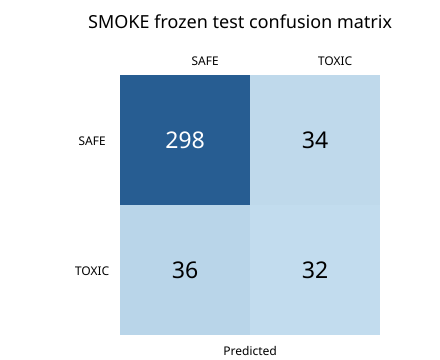

In [10]:
matrix = np.asarray(test_metrics["confusion_matrix"]["rows_true_columns_predicted"])
fig, ax = plt.subplots(figsize=(5,4)); image = ax.imshow(matrix, cmap="Blues")
ax.set(xticks=range(2), yticks=range(2), xticklabels=BINARY_LABELS, yticklabels=BINARY_LABELS, xlabel="Predicted", ylabel="True", title="Frozen test confusion matrix")
for i in range(2):
    for j in range(2): ax.text(j, i, int(matrix[i,j]), ha="center", va="center")
fig.colorbar(image, ax=ax); fig.tight_layout(); fig.savefig(OUTPUT_DIR / "test_confusion_matrix.png", dpi=150); plt.show()

## 11. Phân tích lỗi không chứa raw text

In [11]:
analysis = pd.DataFrame({"text": test_df.text, "truth": test_df.label, "prediction": test_prediction})
analysis["correct"] = analysis.truth == analysis.prediction; analysis["length"] = analysis.text.str.len()
mistakes = analysis.loc[~analysis.correct]
private_errors = {"privacy": "aggregate_and_fingerprint_only", "post_hoc": True, "total_errors": len(mistakes), "SAFE_as_TOXIC": int(((mistakes.truth=="SAFE") & (mistakes.prediction=="TOXIC")).sum()), "TOXIC_as_SAFE": int(((mistakes.truth=="TOXIC") & (mistakes.prediction=="SAFE")).sum()), "fingerprint_prefixes": [fingerprint(text)[:16] for text in mistakes.text.head(20)]}
write_json(OUTPUT_DIR / "error_analysis.json", private_errors)

## 12. Luồng hệ thống AI: input → preprocess → SAFE/TOXIC → warning → human review
Ví dụ bên dưới là câu trung tính tự tạo; hàm không echo input.

In [12]:
def system_decision(text):
    label = str(frozen_model.predict([text])[0])
    if hasattr(frozen_model, "predict_proba"):
        classes = list(frozen_model.classes_); confidence = float(frozen_model.predict_proba([text])[0][classes.index(label)])
    else:
        score = float(frozen_model.decision_function([text])[0]); p_toxic = 1/(1+math.exp(-max(-50,min(50,score)))); confidence = p_toxic if label=="TOXIC" else 1-p_toxic
    uncertain = confidence < 0.65
    return {"label": label, "confidence_proxy": round(confidence,6), "warning_level": ("HIGH" if confidence>=0.8 else "MEDIUM") if label=="TOXIC" else ("REVIEW" if uncertain else "LOW"), "warning": "Chuyển human review" if label=="TOXIC" else "Cho phép báo cáo thủ công", "human_review": label=="TOXIC" or uncertain, "flow": ["input","preprocess","SAFE_or_TOXIC","warning","human_review"], "privacy": "input_not_echoed", "scope": "toxicity_not_fake_news"}
system_decision("Chúc mọi người học tập hiệu quả")

## 13. Nhánh nâng cao FULL_WITH_NEURAL: BiLSTM và PhoBERT binary
Hai model vẫn nhận nhãn SAFE/TOXIC trực tiếp, học/select bằng train/dev và không mở test. Checkpoint lớn không được commit.

In [ ]:
if RUN_MODE == "FULL_WITH_NEURAL":
    import copy, torch
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    torch.manual_seed(SEED); device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    processed_train = SocialPreprocessor().transform(train_df.text); processed_dev = SocialPreprocessor().transform(dev_df.text)
    counts = Counter(token for text in processed_train for token in text.split())
    vocab_tokens = [token for token,count in sorted(counts.items(), key=lambda item:(-item[1],item[0])) if count>=2][:39998]
    vocabulary = {"<pad>":0, "<unk>":1, **{token:i+2 for i,token in enumerate(vocab_tokens)}}  # train only
    def encode(texts, max_length=128):
        rows=[]
        for text in texts:
            row=[vocabulary.get(token,1) for token in text.split()[:max_length]]; rows.append(row+[0]*(max_length-len(row)))
        return torch.tensor(rows,dtype=torch.long)
    class BinaryBiLSTM(nn.Module):
        def __init__(self):
            super().__init__(); self.emb=nn.Embedding(len(vocabulary),128,padding_idx=0); self.lstm=nn.LSTM(128,96,batch_first=True,bidirectional=True); self.head=nn.Linear(192,2)
        def forward(self,x):
            _,(h,_)=self.lstm(self.emb(x)); return self.head(torch.cat((h[-2],h[-1]),dim=1))
    bilstm=BinaryBiLSTM().to(device); optimizer=torch.optim.AdamW(bilstm.parameters(),lr=2e-4); loss_fn=nn.CrossEntropyLoss()
    train_x=encode(processed_train); train_y=torch.tensor((train_df.label=="TOXIC").astype(int).to_numpy()); dev_x=encode(processed_dev)
    loader=DataLoader(TensorDataset(train_x,train_y),batch_size=32,shuffle=True); best_bilstm=None; best_bilstm_metric=None
    for epoch in range(3):
        bilstm.train()
        for x,y in loader:
            optimizer.zero_grad(); loss=loss_fn(bilstm(x.to(device)),y.to(device)); loss.backward(); optimizer.step()
        bilstm.eval()
        with torch.no_grad(): pred=bilstm(dev_x.to(device)).argmax(1).cpu().numpy()
        score=metrics(dev_df.label,["TOXIC" if x else "SAFE" for x in pred])
        key=(score["macro"]["f1"],score["per_class"]["TOXIC"]["recall"])
        if best_bilstm_metric is None or key>best_bilstm_metric: best_bilstm_metric=key; best_bilstm=(epoch+1,score,copy.deepcopy(bilstm.state_dict()))
    torch.save({"state_dict":best_bilstm[2],"vocabulary":vocabulary,"labels":BINARY_LABELS},OUTPUT_DIR/"bilstm_binary.best.pt")
    from transformers import AutoModelForSequenceClassification, AutoTokenizer
    checkpoint="vinai/phobert-base-v2"; tokenizer=AutoTokenizer.from_pretrained(checkpoint,revision="main")
    phobert=AutoModelForSequenceClassification.from_pretrained(checkpoint,revision="main",num_labels=2,id2label={0:"SAFE",1:"TOXIC"},label2id={"SAFE":0,"TOXIC":1}).to(device)
    optimizer=torch.optim.AdamW(phobert.parameters(),lr=2e-5); best_phobert=None; best_phobert_metric=None
    def batches(texts,labels,batch_size=16):
        for start in range(0,len(texts),batch_size):
            encoded=tokenizer(texts[start:start+batch_size],padding=True,truncation=True,max_length=128,return_tensors="pt"); encoded={k:v.to(device) for k,v in encoded.items()}; encoded["labels"]=torch.tensor([1 if x=="TOXIC" else 0 for x in labels[start:start+batch_size]],device=device); yield encoded
    for epoch in range(3):
        phobert.train()
        for batch in batches(processed_train,train_df.label.tolist()): optimizer.zero_grad(); output=phobert(**batch); output.loss.backward(); optimizer.step()
        phobert.eval(); pred=[]
        with torch.no_grad():
            for batch in batches(processed_dev,dev_df.label.tolist()): pred.extend(phobert(input_ids=batch["input_ids"],attention_mask=batch["attention_mask"]).logits.argmax(1).cpu().tolist())
        score=metrics(dev_df.label,["TOXIC" if x else "SAFE" for x in pred]); key=(score["macro"]["f1"],score["per_class"]["TOXIC"]["recall"])
        if best_phobert_metric is None or key>best_phobert_metric: best_phobert_metric=key; best_phobert=(epoch+1,score,copy.deepcopy(phobert.state_dict()))
    phobert.load_state_dict(best_phobert[2]); phobert.save_pretrained(OUTPUT_DIR/"phobert_binary.best"); tokenizer.save_pretrained(OUTPUT_DIR/"phobert_binary.best")
    write_json(OUTPUT_DIR/"neural_results.json",{"selection_split":"dev","test_opened":False,"bilstm":{"best_epoch":best_bilstm[0],"dev":best_bilstm[1]},"phobert":{"best_epoch":best_phobert[0],"dev":best_phobert[1]}})

## 14. Tái lập và kết luận
`manifest.json`, `dev_results.json`, `selection.lock.json`, `test_results.json`, confusion matrix và error analysis đã được xuất. Khi trình bày, dùng `FULL`; `SMOKE` chỉ chứng minh notebook chạy. Kết quả là reproduction/post-hoc, không phải benchmark chính mới.